# Auxiliary plots

In [1]:
from pathlib import Path
import importlib

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import plot_basics
import finn.config
import finn.model as fmodel
import finn.io as fio

importlib.reload(plot_basics)
importlib.reload(finn.config)
importlib.reload(fmodel)
importlib.reload(fio)

from finn.config import Params

Setup directories

In [2]:
input_dir = Path("../in")
output_dir = Path("../out")
results_dir = output_dir / "results"
image_output_dir = results_dir / "images"

image_output_dir.mkdir(exist_ok=True, parents=True)

Parametric isotherms

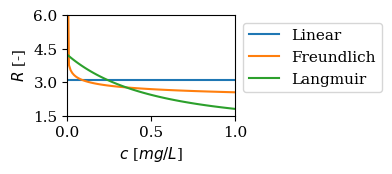

In [3]:
fig, ax = plt.subplots(figsize=(1.35*plot_basics.FIGURE_WIDTH, plot_basics.FIGURE_HEIGHT))

conc = np.linspace(0.0, 1.0, 100)

anRet = fmodel.AnalyticRetardation()

core2_cfg = fio.load_exp_cfg("Core 2")

params = Params.from_dict(**core2_cfg)

linear = anRet.linear(conc, params.por, params.rho_s, params.Kd)
freundlich = anRet.freundlich(conc, params.por, params.rho_s, params.Kf, params.nf)  
langmuir = anRet.langmuir(conc, params.por, params.rho_s, params.smax, params.Kl)

ax.plot(conc, linear, "-", label="Linear")
ax.plot(conc, freundlich, "-", label="Freundlich")
ax.plot(conc, langmuir, "-", label="Langmuir")

ax.set_xlim(0.0, 1.0)
ax.set_ylim(1.5, 6)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plot_basics.set_retardation_axes_stuff(ax, set_xlabel=True, set_ylabel=True)
plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "parametric_isotherms")
plt.show()

Concentration field

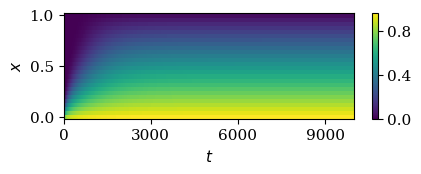

In [4]:
fig, ax = plt.subplots(figsize=(1.5*plot_basics.FIGURE_WIDTH, plot_basics.FIGURE_HEIGHT))

conc_full = np.load(input_dir / f"forward/c_langmuir.npy")
Nt, _, Nx = conc_full.shape 

x = np.linspace(0, 1, Nx)
t = np.linspace(0, 10000, Nt)

plt.pcolor(t, x, conc_full[:, 0, :].T)

plt.xlabel("$t$")
plt.ylabel("$x$")
# plt.title("Concentration Field $c(x,t)$")
cbar = plt.colorbar()
cbar.set_ticks([0, 0.4, 0.8])
ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
ax.yaxis.set_major_locator(ticker.FixedLocator([0, 0.5, 1.0]))

plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "concentration_field")
plt.show() 

Mixed quantile sampling

Training mean network...
Training upper network with 18 points...
Training lower network with 12 points...
Generating sample points...
Creating visualization...


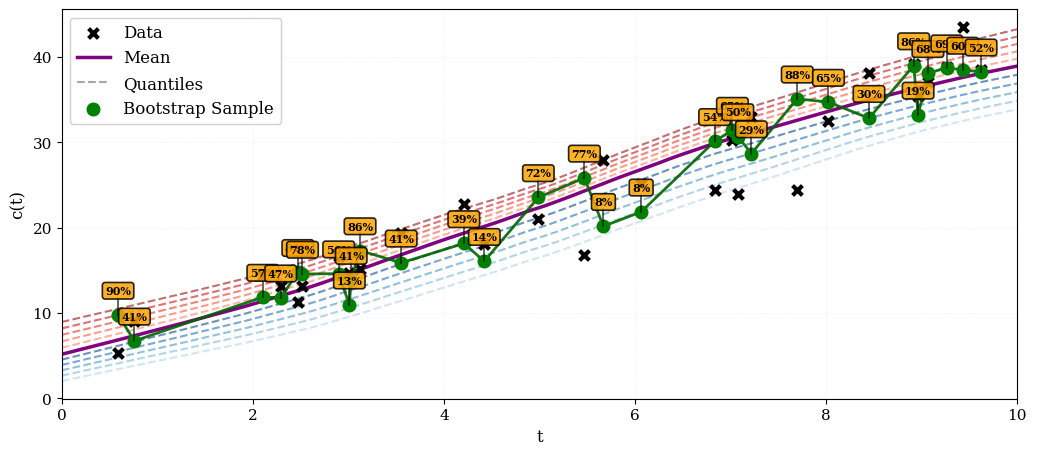

In [5]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(49)

# Generate scattered data
n_points = 30
x = np.random.uniform(0, 10, n_points)
# Create y values with some trend and noise
y = 2 * x + 5 + np.random.normal(0, 3, n_points) + 0.5 * x**1.5

# Reshape for sklearn
X = x.reshape(-1, 1)

# Scale the data
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print("Training mean network...")
# Stage 1: Train mean network
mean_network = MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=2000, 
                           random_state=42, early_stopping=True)
mean_network.fit(X_scaled, y_scaled)
y_mean_scaled = mean_network.predict(X_scaled)
y_mean = scaler_y.inverse_transform(y_mean_scaled.reshape(-1, 1)).ravel()

# Calculate residuals
residuals = y - y_mean

# Stage 2: Split into upper and lower datasets
upper_mask = residuals >= 0
lower_mask = residuals < 0

X_upper = X_scaled[upper_mask]
y_upper = np.abs(residuals[upper_mask])
X_lower = X_scaled[lower_mask]
y_lower = np.abs(residuals[lower_mask])

print(f"Training upper network with {len(X_upper)} points...")
# Train upper network (for positive residuals)
upper_network = MLPRegressor(hidden_layer_sizes=(30, 30), max_iter=2000, 
                            random_state=42, early_stopping=True)
upper_network.fit(X_upper, y_upper)

print(f"Training lower network with {len(X_lower)} points...")
# Train lower network (for negative residuals)
lower_network = MLPRegressor(hidden_layer_sizes=(30, 30), max_iter=2000, 
                            random_state=42, early_stopping=True)
lower_network.fit(X_lower, y_lower)

# Stage 3: Generate quantile predictions via root finding
x_line = np.linspace(0, 10, 100)
X_line = x_line.reshape(-1, 1)
X_line_scaled = scaler_x.transform(X_line)

# Predict mean for the line
y_line_mean = scaler_y.inverse_transform(
    mean_network.predict(X_line_scaled).reshape(-1, 1)
).ravel()

# Predict upper and lower bounds
y_line_upper_bound = upper_network.predict(X_line_scaled)
y_line_lower_bound = lower_network.predict(X_line_scaled)

# Generate quantile lines by scaling the bounds
quantiles = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
quantile_lines_upper = {}
quantile_lines_lower = {}

for q in quantiles:
    if q >= 0.5:
        # Upper quantiles: scale the upper bound
        alpha = (q - 0.5) / 0.5  # 0 at median, 1 at q=1
        quantile_lines_upper[q] = y_line_mean + alpha * 2 * y_line_upper_bound
    else:
        # Lower quantiles: scale the lower bound
        alpha = (0.5 - q) / 0.5  # 0 at median, 1 at q=0
        quantile_lines_lower[q] = y_line_mean - alpha * 2 * y_line_lower_bound

# Sample points: for each data point, randomly select a quantile
print("Generating sample points...")
sample_x = x.copy()
sample_quantiles = np.random.uniform(0.08, 0.95, len(x))

# For each sample, predict y at its quantile
sample_y = []
X_sample_scaled = scaler_x.transform(sample_x.reshape(-1, 1))
y_sample_mean = scaler_y.inverse_transform(
    mean_network.predict(X_sample_scaled).reshape(-1, 1)
).ravel()
y_sample_upper_bound = upper_network.predict(X_sample_scaled)
y_sample_lower_bound = lower_network.predict(X_sample_scaled)

for i, sq in enumerate(sample_quantiles):
    if sq >= 0.5:
        alpha = (sq - 0.5) / 0.5
        sample_y.append(y_sample_mean[i] + alpha * 2 * y_sample_upper_bound[i])
    else:
        alpha = (0.5 - sq) / 0.5
        sample_y.append(y_sample_mean[i] - alpha * 2 * y_sample_lower_bound[i])

sample_y = np.array(sample_y)

# Create the plot
print("Creating visualization...")
fig, ax = plt.subplots(figsize=(3.5*plot_basics.FIGURE_WIDTH, 2.5*plot_basics.FIGURE_HEIGHT))

# Plot scattered data
ax.scatter(x, y, s=50, c="black", marker="x", 
          linewidth=3, label="Data", zorder=3)

# Plot mean line
ax.plot(x_line, y_line_mean, "-", linewidth=2.5, label="Mean", color="purple", zorder=2)

# Plot quantile lines
colors_upper = plt.cm.Reds(np.linspace(0.3, 0.9, len([q for q in quantiles if q >= 0.5])))
colors_lower = plt.cm.Blues(np.linspace(0.3, 0.9, len([q for q in quantiles if q < 0.5])))

# Plot lower quantile lines (no individual labels)
for q, color in zip([q for q in quantiles if q < 0.5], colors_lower):
    ax.plot(x_line, quantile_lines_lower[q], "--", alpha=0.6, linewidth=1.5,
            color=color, zorder=1)

# Plot upper quantile lines (no individual labels)
for q, color in zip([q for q in quantiles if q >= 0.5], colors_upper):
    ax.plot(x_line, quantile_lines_upper[q], "--", alpha=0.6, linewidth=1.5,
            color=color, zorder=1)

# Add one representative dashed grey line with a label
ax.plot([], [], "--", color="grey", alpha=0.7, linewidth=1.5, label="Quantiles")

# Sort sample points by x-coordinate for connecting line
sorted_indices = np.argsort(sample_x)
sorted_x = sample_x[sorted_indices]
sorted_y = sample_y[sorted_indices]
sorted_q = sample_quantiles[sorted_indices]

# Draw connecting line through samples
ax.plot(sorted_x, sorted_y, "darkgreen", linewidth=2.0, alpha=0.9, zorder=4)

# Plot sample points with flags
# First one gets label for legend
first_sample = True
for sx, sy, sq in zip(sorted_x, sorted_y, sorted_q):
    # Plot the point
    if first_sample:
        ax.scatter(sx, sy, s=50, c="green", marker="o", 
                  linewidth=3, zorder=5, label="Bootstrap Sample")
        first_sample = False
    else:
        ax.scatter(sx, sy, s=50, c="green", marker="o", 
                  linewidth=3, zorder=5)
    
    # Add a flag (line + text box)
    flag_height = 2.0
    ax.plot([sx, sx], [sy, sy + flag_height], "k-", linewidth=1.2, zorder=5, alpha=0.7)
    
    # Add text box with quantile
    bbox_props = dict(boxstyle="round,pad=0.25", facecolor="orange", 
                     edgecolor="black", linewidth=1.2, alpha=0.85)
    ax.text(sx, sy + flag_height + 0.2, f"{int(sq*100)}%", 
           fontsize=8, fontweight="bold", ha="center", va="bottom",
           bbox=bbox_props, zorder=6)

ax.tick_params(axis="x", labelbottom=True)
ax.tick_params(axis="y", labelleft=True)
ax.set_xlabel("t", fontsize=12)
ax.set_ylabel("c(t)", fontsize=12)
ax.legend(loc="upper left", fontsize=12, framealpha=0.9, ncol=1)
ax.grid(True, alpha=0.3, linestyle=":", linewidth=0.5)
ax.autoscale(enable=True, axis="x", tight=True)

plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "quantile_sampling")
plt.show()


Experimental data

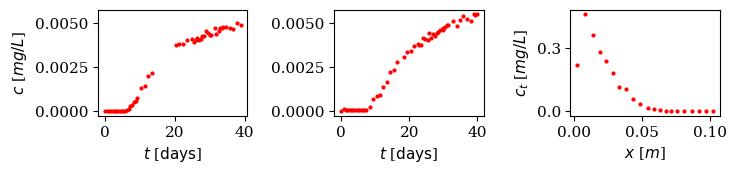

In [6]:
fig, axs = plt.subplots( ncols=3, figsize=(2.5 * plot_basics.FIGURE_WIDTH, plot_basics.FIGURE_HEIGHT))

CORE_DATA_PLOT_KWARGS = dict(
    alpha=1.0,
    s=4.0,
    color="r",
    zorder=1000,
)

for ax, core in zip(axs, ["1", "2", "2B"]):
    ax.scatter(*fio.load_exp_data_numpy(f"Core {core}"), **CORE_DATA_PLOT_KWARGS)
    plot_basics.set_concentration_axes_stuff(ax, set_xlabel=True, set_ylabel=core != "2", core=core)
axs[0].sharey(axs[1])
# axs[1].set_yticklabels([])
# axs[1].tick_params(axis='y', which='both', labelleft=False)
# plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plot_basics.savefig(fig, image_output_dir / "exp_data")
plt.show()